In [ ]:
import numpy as np
from scipy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import sympy as sp
#!pip install OptiCommPy
from IPython.display import display, Math, Latex
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample
from optic.utils import parameters, dBm2W
from optic.models.devices import mzm, photodiode
from optic.plot import eyediagram

## Sumário
---
- [Introdução a comunicações ópticas](#introdução-a-comunicações-ópticas)
- [Tipos de transmissores](#tipos-de-transmissores)
- [Representações para a portadora óptica](#representações-para-a-portadora-óptica)
- [Modulações digitais](#modulações-digitais)


## __Introdução a comunicações ópticas__ <a id="Introdução a comunicações ópticas"></a>
---

Qualquer sistema que emite a luz para transformar informações pode ser considerado um sistema de conunicações ópticas. O sucesso de um sistema de comunicações ópticas está relacionada à capacidade de transmitir grandes volumes de tráfego por longas distâncias. Redes de comunicação possuem sua hierarquia que sustenta a distribuição de internet e uma capacidade máxima de operação. Com o surgimento de várias plataformas e serviços a demanda cresce muito e ao atingir a capacidade máxima a rede entra em colapso. Para solucionar esse problema novas tecnologias devem ser implementadas.

Em comunicações ópticas usamos ondas com frequências que variam de $10^{12} Hz$ até $luz \ visível$, as frequências acima disso são muito prejudiciais a saúde e não é interessante. Um fenomêno interessnte para a fibra óptica é a __refração total__, que ao jogar um feixe de luz a um determinado ângulo ele fica confinado e é refletido toda vez que atingir a parede da guia.

<center><img src="https://descomplica-blog-production.s3-sa-east-1.amazonaws.com/2015/09/tir.jpg" width="30%" style="display:inline-block; margin-right:5%;"/>
<img src="http://descomplica-blog-production.s3-sa-east-1.amazonaws.com/2015/09/r9QOR8Y.jpg" width="55%" style="display:inline-block;"/></center>
$$\text{Fonte: Descomplica: Aprenda tudo sobre refração da luz!}$$

  - Vantagens de sistemas de cominicações ópticas.
    + larga faixa de frequência com baixa atenuação _(de 4 a 10 THz)_
      $$ \frac{Fibra \ óptica}{Conexão \ 4G} = \frac{4 \ THz}{20 \ MHz} = \frac{4.10^{12}}{20.10^{7}} = 200.000 \ \text{usúarios}$$

    + baixo custos por bit transmitido;
    + Desafios:
      - Aumento da capacidade das redes,
      - eficiência ebergética,
      - capacity crunch.

Na fibra acontece a refração, pois ela funciona como espelhos, assim:
$$\begin{equation}
R_n = \left(\frac{n1 - n2}{n1 + n2}\right) = \left(\frac{na - 1}{na + 1}\right), n_2\text{ = AR = 1}
\end{equation}$$

__Perdas:__ $g = α_{int} + \frac{1}{2L}ln\left(\frac{1}{R1R2}\right) = α_{int} + α_{mir}$

__Fase:__ $V_m = \frac{mc}{2nL}$

### __Tipos de transmissores:__ <a id="Tipos de transmissores"></a>
---

  - Directly-modulated lasers (DML):
    + Muito ruído
  - Externally-modulated lasers (EML):
    + Baixa razão de extinção (≈ 10bB);
    + Alta perda de inserção (≈ 10dB).
  - Mach-Zehnder Modulators (MZMs):
    + Alta razão de extinção (≈ 20bB);
    + Baixa perda de inserção (≈ 5dB);
    + Principio da Interferência controlada por modulação de fase.

Em um sistema de comunicação digital, o transmissor transforma uma sequência de bits em um conjunto de pulsos elétricos, que depois são usados para modular uma portadora óptica. A representação abaixo ilustra esse processo.
<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/gerador%20de%20sinais%20.png?raw=true" width="50%"/></center>

$$\text{Fonte: Anotações do professor Edson}$$

### __Representações para a portadora óptica__ <a id="Representações para a portadora óptica"></a>
---

O campo elétrico $E(t)$ de uma portadora óptica em onda contínua pode ser descrito matematicamente da seguinte forma:
$$\begin{equation}E(t)=Acos(ω_ct+θ)e\end{equation}$$

Aqui, $A$ representa a amplitude da onda, $ω_c$  é a frequência angular da portadora, $θ$ é a fase inicial e o vetor __e__ representa o vetor de polarização. Essa equação modela a propagação da onda eletromagnética e é fundamental para entender a modulação e transmissão de sinais em sistemas ópticos.




In [ ]:
θ, omega_c, A, t = sp.symbols("θ, omega_c, A, t", real = True)
j = sp.I
π = sp.pi
E = A * sp.cos(omega_c * t + θ)
display(Math("E(t) = "+ sp.latex(E)))

E = sp.expand_trig(E)
display(Math("E(t) = "+ sp.latex(E)))

Ai = sp.re(A*sp.exp(j*θ))
Aq = sp.im(A*sp.exp(j*θ))
print("Representação cartesiana:")
display(Math("E(t) = "+ sp.latex(Ai + j*Aq)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Representação cartesiana:


<IPython.core.display.Math object>

### **Modulador de Mach-Zehnder**  
---

<center><img src= "https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/Modulador%20Mach-zehnder.png?raw=True" width="60%"/></center>

$$\begin{equation}
\begin{bmatrix}
\hat{E_1} \\
\hat{E_2}
\end{bmatrix} =
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & j \\
j & 1
\end{bmatrix}
\begin{bmatrix}
e^{jϕ_1} & 0 \\
0 & e^{jϕ_2}
\end{bmatrix}
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & j \\
j & 1
\end{bmatrix}
\begin{bmatrix}
\hat{E_i} \\
0
\end{bmatrix}
\end{equation}$$

O modulador de Mach-Zehnder é um dispositivo óptico fundamental em sistemas de comunicações coerentes. Ele divide a energia da entrada igualmente entre dois caminhos, cada um recebendo 50% do sinal incidente. Esse comportamento caracteriza sua atenuação de **3 dB**.  

Cada caminho do modulador possui um atraso diferente, o que pode ser descrito por **matrizes unitárias**, garantindo que a energia do sistema seja preservada. O sinal entra por um lado e se propaga por dois "braços", onde ocorre uma modulação por interferência.  

A configuração **push-pull** desse sistema faz com que exista um ponto em comum entre os acoplamentos ópticos. Em cada braço do modulador, aplicamos tensões \( u_1(t) \) e \( u_2(t) \), sendo uma positiva e a outra negativa. Esse mecanismo permite controlar a fase do sinal óptico de saída, modulando a intensidade e garantindo um comportamento eficiente na transmissão de dados.

In [ ]:
# Definindo símbolos
ϕ, ϕ1, ϕ2 = sp.symbols('ϕ, ϕ1, ϕ2', real=True)
Ai = sp.symbols('A_i', real=True)

# Matriz C
C = 1/sp.sqrt(2) * sp.Matrix([[1, j], [j, 1]])
display(Math('C = ' + sp.latex(C)))

# Matriz M
M = sp.Matrix([[sp.exp(j*ϕ1), 0], [0, sp.exp(j*ϕ2)]])
display(Math('M = ' + sp.latex(M)))

# Operação T (transposta conjugada de C)
T = C*M*C
display(Math('T = ' + sp.latex(T)))

# Vetor Ei
Ei = sp.Matrix([[Ai], [0]])
display(Math(r'\hat{E}_i = ' + sp.latex(Ei)))

# Vetor Saída
E0 = T*Ei
display(Math('\hat{E}_o = ' + sp.latex(E0)))

E0[1].subs({ϕ1:ϕ, ϕ2:-ϕ}).simplify()


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

I*A_i*cos(ϕ)

Assim temos que as expressões podem ser representadas por:

$$\begin{equation}
\frac{\hat{E}_{out}(t)}{\hat{E}_{in}(t)} =
\frac{1}{2}(e^{jϕ(t)} + e^{-jϕ(t)})e^{j\frac{π}{2}}
\end{equation}$$

$$\begin{equation}
ϕ(t) = \frac{1}{2V_r}[u(t) + V_b]π
\end{equation}$$

$$\begin{equation}
A_{out}(t) = A_{in}(t) cos\left(\frac{1}{2V_r}[u(t) + V_b]π\right)
\end{equation}$$

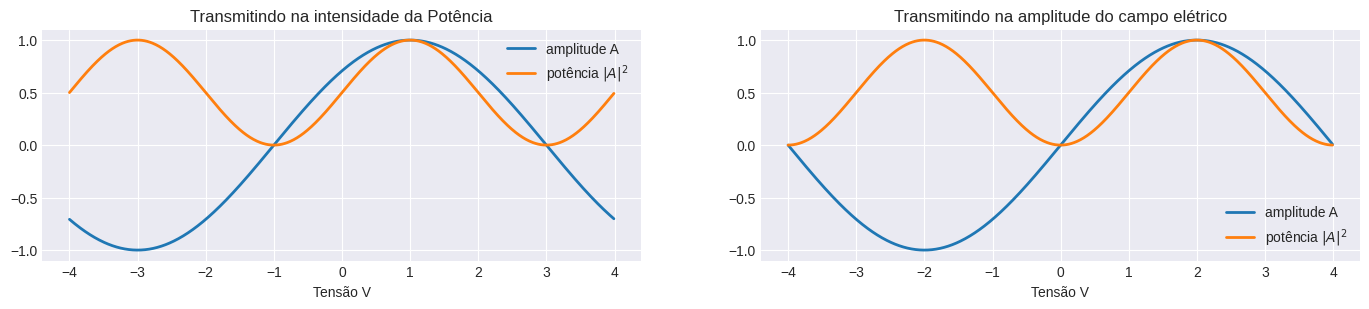

Razão de Extinção (ER) = 30.44522437723423 dB


In [ ]:
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)

u = np.arange(-2*paramMZM.Vpi, 2*paramMZM.Vpi, 0.01)        # Gera valores aleatórios entre -2*Vπ e 2*Vπ

Ai = 1
A0 = mzm(Ai, u, paramMZM)

fig, axis = plt.subplots(1, 2, figsize=(17, 3))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].plot(u, A0, label="amplitude A", linewidth = 2)
axis[0].plot(u, np.abs(A0)**2, label="potência $|A|^2$", linewidth = 2)
axis[0].set_title("Transmitindo na intensidade da Potência")
axis[0].set_xlabel("Tensão V")
axis[0].legend()

paramMZM.Vb = (-paramMZM.Vpi)
A0 = mzm(Ai, u, paramMZM)

axis[1].plot(u, A0, label="amplitude A", linewidth = 2)
axis[1].plot(u, np.abs(A0)**2, label="potência $|A|^2$", linewidth = 2)
axis[1].set_title("Transmitindo na amplitude do campo elétrico")
axis[1].set_xlabel("Tensão V")
axis[1].legend()

plt.show()
P = 10*np.log(np.abs(A0)**2 + 0.05)
print("Razão de Extinção (ER) =", max(P)-min(P), "dB")

### **Razão de extinção**

$$\begin{equation}
ER_{db} = 10 log_{10} \left( \frac{P_1}{P_0} \right)
\end{equation}$$

Quanto maior a razão de extinção melhor, pois o sistema irá separar melhor o que é o bit "1" ou o bit "0".

### **Intervalos de sinalização**

Transmissores digitais transmitem informações com uma base de tempo chamada _intervalo de sinalização_ $Ts$, o inverso é chamado de _taxa de transmissão de símbolos_ $Rs$. A taxa de transmissão de bits do sistema é dado por: $Rb = kRs$

### **teorema de amostragem**

Esse teorema estabelece uma conclusão suficiente para uma taxa de amostragem que permite que uma sequência discreta de amostras capture toda informação.
Considere um sinal $x(t)$ limitado em banda e o espectro de frequência $X(f)$ está contido no intervalo $-B < fa < B$.

Se $fa \ge 2B$, x(t) pode ser perfeitamente reconstruido a partir de suas amostras $x(k)$, pela sequinte equação:
$$\begin{equation}
x(t) = \sum_{k = -∞}^{∞}x(kT_a)sinc\left(\frac{t - kT_a}{T_a}\right)
\end{equation}$$

Os códigos abaixo simulam um sinal contínuo e mostram na prática como a taxa de amostragem afeta a reconstrução do sinal original. A gente começa criando um sinal analógico suave, depois amostra ele em intervalos regulares - é como tirar várias fotos rápidas de um sinal em movimento.Se amostrarmos com uma frequência de amostragem baixa, o sinal reconstruído fica todo distorcido, perdemos detalhes importantes. Mas quando seguimos a regra de Nyquist (amostrar pelo menos no dobro da frequência máxima do sinal), conseguimos recuperar quase perfeitamente o sinal original. Os gráficos mostram exatamente isso - o sinal original, os pontos de amostragem e como fica o sinal depois da reconstrução. Quanto mais amostras, mais fiel fica a reprodução do sinal!

In [ ]:
def sincInterp(x, fa):

    fa_sinc = 32*fa
    Ta_sinc = 1/fa_sinc
    Ta = 1/fa
    t = np.arange(0, x.size*32)*Ta_sinc

    y = upsample(x,32)
    y[y==0] = np.nan

    x_sum = 0
    for k in range(0, x.size):
        xk_interp = x[k]*np.sinc((t-k*Ta)/Ta)
        x_sum += xk_interp

    return x_sum, t

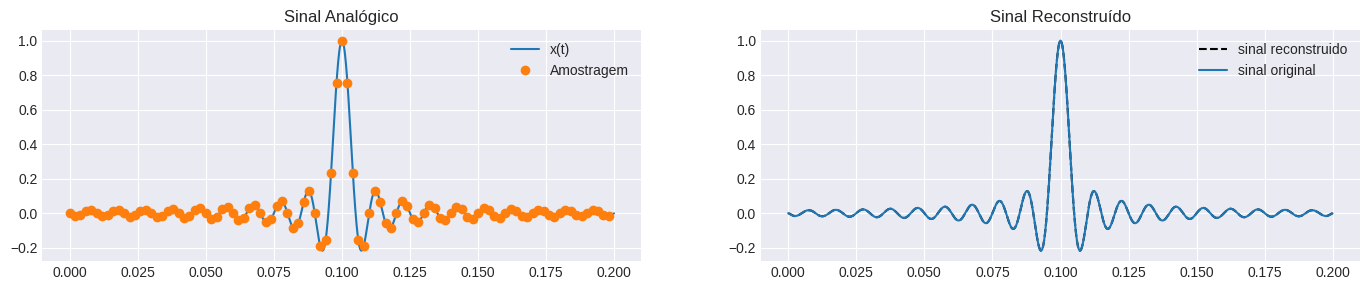

In [ ]:
Fa = 500                      # frequência de amostragem
B = 100                       # banda do sinal
Ta = 1/Fa                     # Taxa de amostragem

t = np.arange(0, 0.2, Ta/16)  #duração do sinal
d = t.size/2                  #deixa o sinal simetrico
x = np.sinc(2*B*(t-d*(Ta/16)))#cria o sinal sinc

# Fazendo a amostragem do sinal, deixando com menos pontos.
xa = x[::16]
ta = t[::16]

plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 2, figsize=(17, 3))
axis[0].plot(t, x, label = "x(t)")
axis[0].plot(ta, xa, 'o', label = "Amostragem")
axis[0].set_title("Sinal Analógico")
axis[0].legend()

x_int, t_int = sincInterp(xa, Fa)
axis[1].plot(t_int, x_int, "--k", label="sinal reconstruido")
axis[1].plot(t,x, label="sinal original")
axis[1].set_title("Sinal Reconstruído")
axis[1].legend()

plt.show()

Para visualizar os exemplos clique no link: [Códigos de Comunicações Ópticas](https://github.com/Medupl/PIBITI/blob/main/Capacitacao/Comunicacoes-Opticas/Codigos_de_C_O.ipynb)

### Chaveamento por deslocamento de amplitude ASK/PAM
---

No código abaixo, implementamos um transmissor digital que gera uma sequência de bits aleatória, converte esses bits em sinais discretos usando modulação por amplitude (ASK/PAM - onde 0 é mapeado para -1V e 1 para +1V no caso binário), e finalmente formata esses símbolos através de um pulso retangular ideal para criar o sinal elétrico transmitido, demonstrando na prática os princípios do chaveamento por deslocamento de amplitude, técnica fundamental em comunicações digitais que codifica informação na variação da amplitude do sinal.

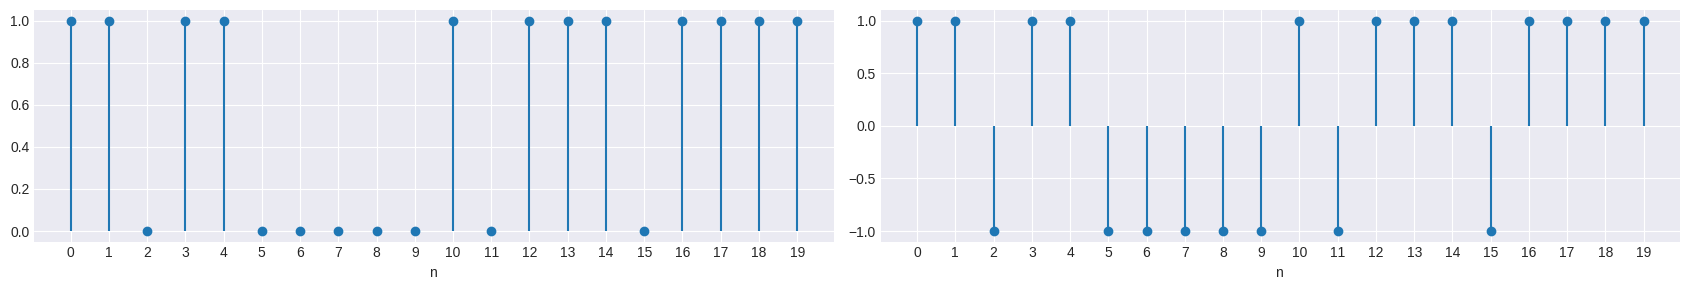

In [ ]:
Rs = 10e9                                       # Taxa de simbolos
Ts = 1/Rs                                       # Periodo de simbolos

bits = np.random.randint(2, size=20)
n = np.arange(0,bits.size)

#mapeia bits para simbolos binarios para gerar sinais eletricos.
symb = 2*bits-1

fig, axis = plt.subplots(1, 2, figsize=(17, 3))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].stem(bits, basefmt=" ")
axis[0].set_xlabel("n")
axis[0].set_xticks(n)

axis[1].stem(symb, basefmt=" ")
axis[1].set_xlabel("n")
axis[1].set_xticks(n)

plt.tight_layout()
plt.show()

### Gerando sinais OOK
---

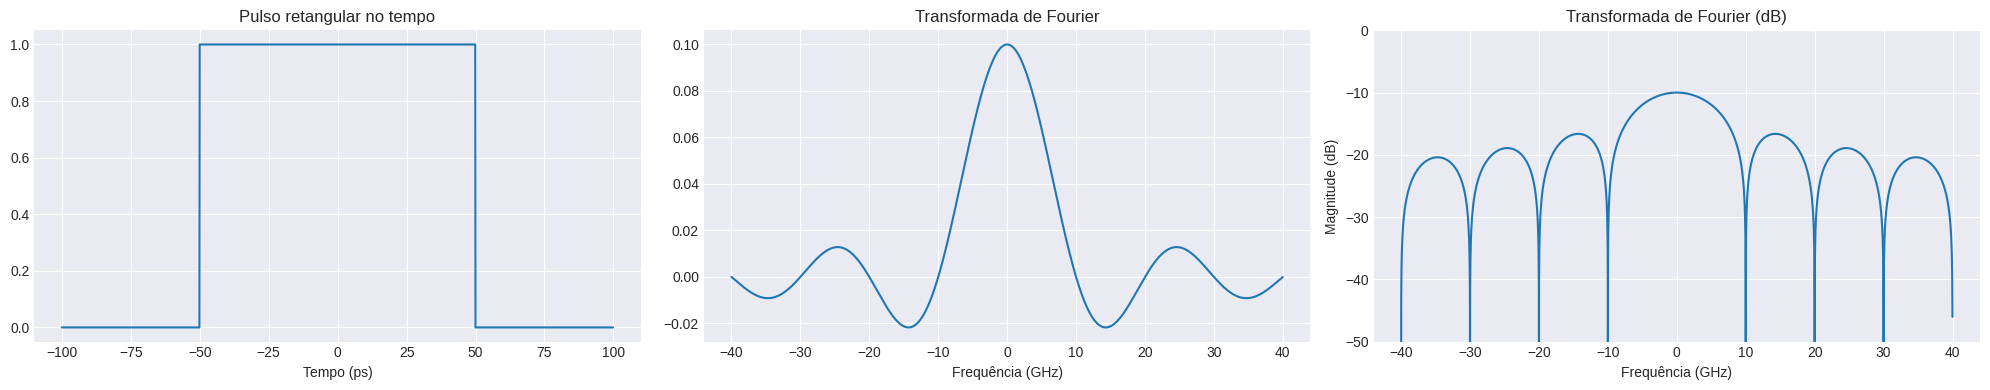

In [ ]:
# Definições simbólicas
Ts = sp.symbols('T_s', real=True, positive=True)
t, f = sp.symbols('t, f', real=True)

#Função retangular e sua transformada
def rect(t, a):
    return sp.Heaviside(t + a) - sp.Heaviside(t - a)

p = rect(t, Ts/2)
P = sp.fourier_transform(p, t, f)

# Substituição numérica
Rs = 10e9                                       # Taxa de simbolos
Ts_num = 1/(Rs/1e12)                            # Período em picossegundos
t_vals = np.arange(-1, 1, 0.001)*(1/(Rs/1e12))
p_num = sp.lambdify(t, p.subs(Ts, Ts_num), 'numpy')(t_vals)

f_vals = np.arange(-4, 4, 0.001)*(Rs/1e9)
P_num = sp.lambdify(f, P.subs(Ts, 1/(Rs/1e9)), 'numpy')(f_vals)

P_dB = 10 * np.log10(np.abs(P_num) + 1e-22)

# 4. Plot do pulso no tempo
plt.style.use("seaborn-v0_8-darkgrid")
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

ax[0].plot(t_vals, p_num)
ax[0].set_title("Pulso retangular no tempo")
ax[0].set_xlabel("Tempo (ps)")

ax[1].plot(f_vals,(P_num))
ax[1].set_title("Transformada de Fourier")
ax[1].set_xlabel("Frequência (GHz)")

ax[2].plot(f_vals, P_dB)
ax[2].set_title("Transformada de Fourier (dB)")
ax[2].set_xlabel("Frequência (GHz)")
ax[2].set_ylabel("Magnitude (dB)")
ax[2].set_ylim(-50, 0)

plt.tight_layout()
plt.show()

In [ ]:
# parâmetros da simulação
SpS = 128                                       # Parametros de amostra por simbolo
Rs = 10e9                                       # Taxa de simbolos
Ts = 1/Rs                                       # Periodo de simbolos
Fa = 1/(Ts/SpS)                                 # fr de amostragem
Ta = 1/Fa                                       # per de amostragem

# pulso retangular ideal
pulse = pulseShape("rect",SpS)
pulse = pulse/max(abs(pulse))


In [ ]:
# Aumenta a taxa de amostragem, acrescentando zeros.
symbolsUp = upsample(symb,SpS)

# Formatação pelo pulso retangular
sigft = firFilter(pulse, symbolsUp)
sigft = sigft.real
t1 = np.arange(0, sigft.size)*(Ta/1e-12)

#ajustando os ponto de amostragem
symbolsUp = upsample(symb,SpS).astype(np.float64)
symbolsUp[symbolsUp==0] = np.nan
t2 = (0.5 + np.arange(0, bits.size))*(Ts/1e-12)

#Modulação optica
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)

#Definindo a potência da portadora de entrada:
P0 = 100e-3
Ai = np.sqrt(P0)
sigft0 = mzm(Ai, (-paramMZM.Vb)*sigft, paramMZM)
t3 = np.arange(0, sigft0.size)*(Ta/1e-12)

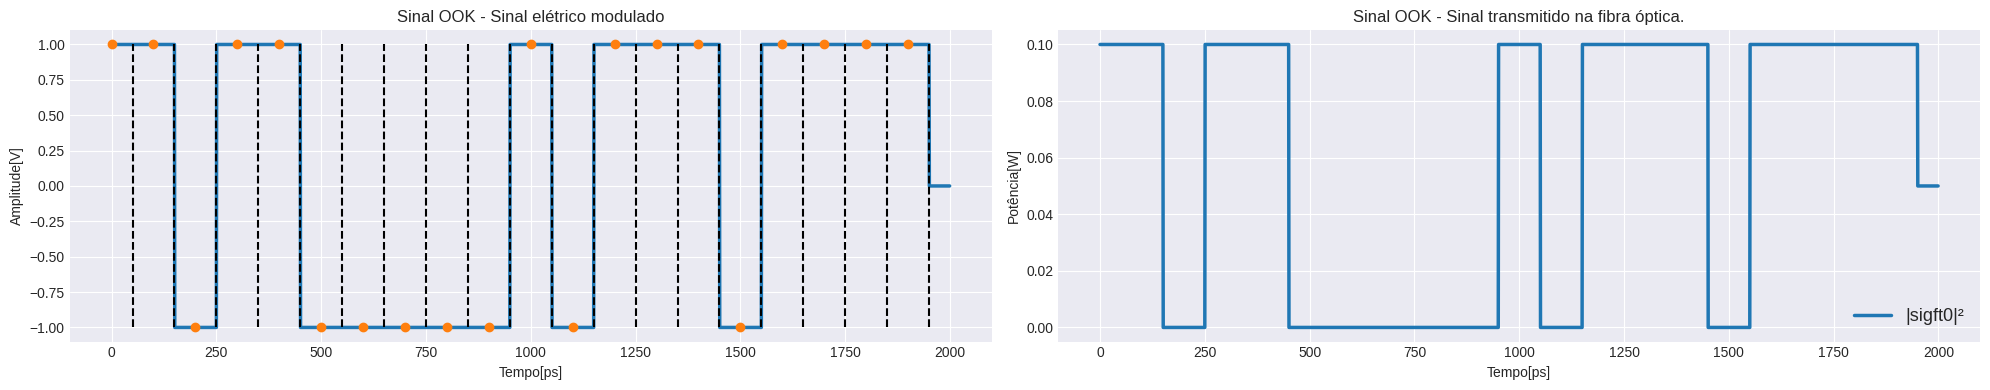

In [ ]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(1, 2, figsize=(20, 4))

axis[0].plot(t1, sigft, "-", linewidth = 2.5)
axis[0].plot(t1, symbolsUp, "o", linewidth = 2.5)
axis[0].vlines(t2, -1, 1, linestyles='dashed', color = 'k')
axis[0].set_xlabel("Tempo[ps]")
axis[0].set_ylabel("Amplitude[V]")
axis[0].set_title("Sinal OOK - Sinal elétrico modulado")

axis[1].plot(t3, np.abs(sigft0)**2, linewidth = 2.5, label = "|sigft0|²")
axis[1].set_xlabel("Tempo[ps]")
axis[1].set_ylabel("Potência[W]")
axis[1].set_title("Sinal OOK - Sinal transmitido na fibra óptica.")
axis[1].legend(loc="best", fontsize = 13)

plt.tight_layout()
plt.show()

Para visualizar outros exemplos clique no link: [Códigos de Comunicações Ópticas](https://github.com/Medupl/PIBITI/blob/main/Capacitacao/Comunicacoes-Opticas/Codigos_de_C_O.ipynb)

### Exmplos de densidade espectral de potência

In [ ]:
Nsamples = 10000
bits = np.random.randint(2,size=Nsamples)
n = np.arange(0,bits.size)
SpS = 128

# mapeia bits para pulsos elétricos
symb = 2*bits-1
symb = symb/np.sqrt(signal_power(symb))

# Aumenta a taxa de amostragem, acrescentando zeros.
symbolsUp = upsample(symb, SpS)

#Gerando pulso NRZ
pulse = pulseShape("nrz",SpS)
pulse = pulse/max(np.abs(pulse))

# formatação de pulso NRZ
sigft = firFilter(pulse, symbolsUp)

#modulação óptica
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)

Po = 100e-3 # potência da portadora CW na entrada no MZM
Ai = np.sqrt(Po)
sigft0 = mzm(Ai, (-paramMZM.Vb)*sigft, paramMZM)

TypeError: unsupported operand type(s) for *: 'Axes' and 'int'

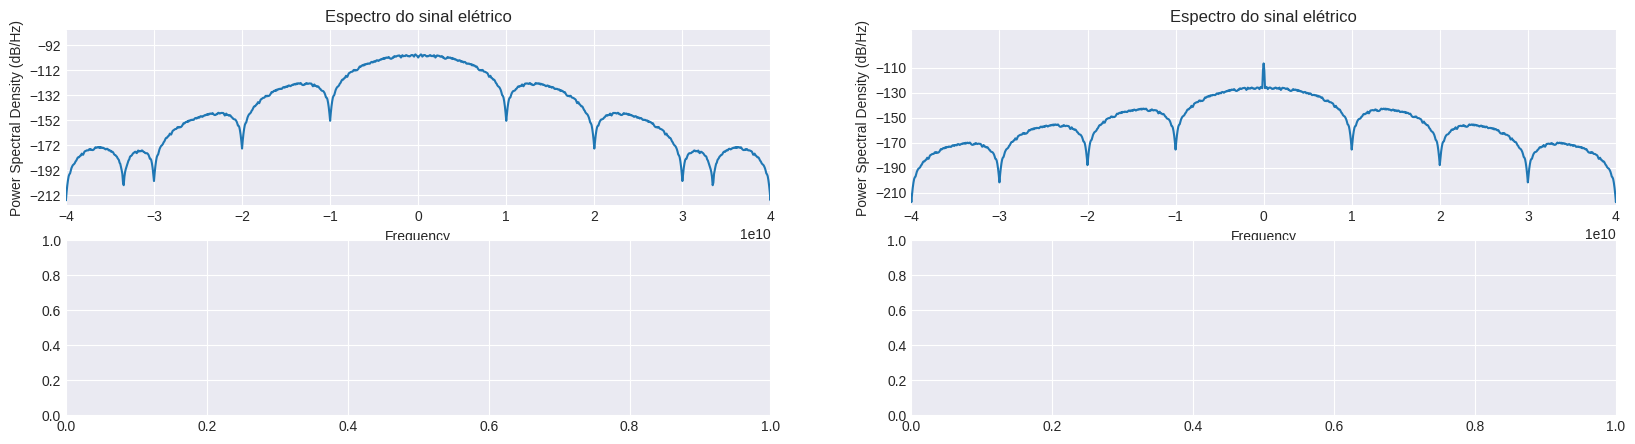

In [ ]:
fig, axis = plt.subplots(2, 2, figsize=(20, 5))

axis[0,0].psd(sigft, Fs=Fa, NFFT = 16*1024, sides='twosided')
axis[0,0].set_xlim(-4*Rs, 4*Rs)
axis[0,0].set_ylim(-220, -80)
axis[0,0].set_title("Espectro do sinal elétrico")

axis[0,1].psd(np.abs(sigft0)**2, Fs=Fa, NFFT = 16*1024, sides='twosided')
axis[0,1].set_xlim(-4*Rs, 4*Rs)
axis[0,1].set_ylim(-220, -80)
axis[0,1].set_title("Espectro do sinal elétrico")

# diagrama de olho
#eyediagram(sigft, sigft.size-SpS, SpS, axis[1,0])
#eyediagram(np.abs(sigft0)**2, Nsamples, SpS)
ey

plt.tight_layout()
plt.show()